In [34]:
import pandas as pd

df_new = pd.read_csv("data/raw/pd_2018_present.csv")
df_old = pd.read_csv('data/raw/pd_2003_2018.csv')

/var/folders/7z/72trz_6j2ss4z5yp7pd0jr_00000gn/T/ipykernel_38464/2982888874.py:3: DtypeWarning: Columns (18,21,26) have mixed types. Specify dtype option on import or set low_memory=False.
  df_new = pd.read_csv("data/raw/pd_2018_present.csv")


In [35]:
print(f"Columns in new: {df_new.columns}")
print(f"Columns in old: {df_old.columns}")


Columns in new: Index(['Row ID', 'Incident Datetime', 'Incident Date', 'Incident Time',
       'Incident Year', 'Incident Day of Week', 'Report Datetime',
       'Incident ID', 'Incident Number', 'CAD Number', 'Report Type Code',
       'Report Type Description', 'Filed Online', 'Incident Code',
       'Incident Category', 'Incident Subcategory', 'Incident Description',
       'Resolution', 'Intersection', 'CNN', 'Police District',
       'Analysis Neighborhood', 'Supervisor District',
       'Supervisor District 2012', 'Latitude', 'Longitude', 'Point',
       'data_as_of', 'data_loaded_at'],
      dtype='object')
Columns in old: Index(['PdId', 'IncidntNum', 'Incident Code', 'Category', 'Descript',
       'DayOfWeek', 'Date', 'Time', 'PdDistrict', 'Resolution', 'Address', 'X',
       'Y', 'location', 'data_loaded_at'],
      dtype='object')


In [36]:
mapping = {
    'IncidntNum': 'Incident Number',
    'Category': 'Incident Category',
    'Date': 'Incident Date',
    'Time': 'Incident Time',
    'PdDistrict': 'Police District',
    'X': 'Latitude',
    'Y': 'Longitude'
}

df_old = df_old.rename(columns=mapping)
df_old = df_old[
            ['Incident Number', 
             'Incident Date', 'Incident Time', 'Incident Code', 
             'Incident Category','Police District', 'Latitude', 'Longitude']
            ]

In [37]:
df_old['Row ID'] = df_old.index
df_old['Incident Datetime'] = df_old['Incident Date'] + " " + df_old['Incident Time']
df_old['Incident Datetime'] = pd.to_datetime(df_old['Incident Datetime'], format='%m/%d/%Y %H:%M')
df_new['Incident Datetime'] = pd.to_datetime(df_new['Incident Datetime'], format='%Y/%m/%d %I:%M:%S %p')


In [38]:
df_new = df_new.drop(df_new[['Incident Subcategory']], axis=1)
df_new.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1006072 entries, 0 to 1006071
Data columns (total 28 columns):
 #   Column                    Non-Null Count    Dtype         
---  ------                    --------------    -----         
 0   Row ID                    1006072 non-null  int64         
 1   Incident Datetime         1006072 non-null  datetime64[ns]
 2   Incident Date             1006072 non-null  object        
 3   Incident Time             1006072 non-null  object        
 4   Incident Year             1006072 non-null  int64         
 5   Incident Day of Week      1006072 non-null  object        
 6   Report Datetime           1006072 non-null  object        
 7   Incident ID               1006072 non-null  int64         
 8   Incident Number           1006072 non-null  int64         
 9   CAD Number                779694 non-null   float64       
 10  Report Type Code          1006072 non-null  object        
 11  Report Type Description   1006072 non-null  object

In [39]:
df_old.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2071736 entries, 0 to 2071735
Data columns (total 10 columns):
 #   Column             Dtype         
---  ------             -----         
 0   Incident Number    int64         
 1   Incident Date      object        
 2   Incident Time      object        
 3   Incident Code      int64         
 4   Incident Category  object        
 5   Police District    object        
 6   Latitude           float64       
 7   Longitude          float64       
 8   Row ID             int64         
 9   Incident Datetime  datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int64(3), object(4)
memory usage: 158.1+ MB


In [40]:
# Make Police districts regular letters, not capital
df_old['Police District'].unique, df_new['Police District'].unique

df_new['Police District'] = pd.Categorical(df_new['Police District'])
df_old['Police District'] = pd.Categorical(df_old['Police District'])

df_new['Police District'] = df_new['Police District'].str.upper()
df_old['Police District'].unique(), df_new['Police District'].unique()


df_new['Incident Category'] = pd.Categorical(df_new['Incident Category'])
df_old['Incident Category'] = pd.Categorical(df_old['Incident Category'])

In [41]:
df_old['Latitude'].head(), df_new['Latitude'].head()

(0   -120.500000
 1   -122.463545
 2   -122.466758
 3   -122.420084
 4   -122.425839
 Name: Latitude, dtype: float64,
 0          NaN
 1    37.780415
 2    37.775177
 3    37.774551
 4    37.769661
 Name: Latitude, dtype: float64)

In [42]:
print(len(df_old['Incident Category'].unique()), len(df_new['Incident Category'].unique()))

new_list = sorted(df_old['Incident Category'].astype(str).unique())
old_list = sorted(df_new['Incident Category'].astype(str).unique())

for i in range(0, len(old_list)-1):
    print(f"{old_list[i]}")
    # if i <= len(old_list)-1:
    #     print(f"    {new_list[i]}")#, {old_list[i]}")
    # else:
    #     print(f"NEW:    {new_list[i]}")

37 50
Arson
Assault
Burglary
Case Closure
Civil Sidewalks
Courtesy Report
Disorderly Conduct
Drug Offense
Drug Violation
Embezzlement
Fire Report
Forgery And Counterfeiting
Fraud
Gambling
Homicide
Human Trafficking (A), Commercial Sex Acts
Human Trafficking (B), Involuntary Servitude
Human Trafficking, Commercial Sex Acts
Larceny Theft
Liquor Laws
Lost Property
Malicious Mischief
Miscellaneous Investigation
Missing Person
Motor Vehicle Theft
Motor Vehicle Theft?
Non-Criminal
Offences Against The Family And Children
Other
Other Miscellaneous
Other Offenses
Prostitution
Rape
Recovered Vehicle
Robbery
Sex Offense
Stolen Property
Suicide
Suspicious
Suspicious Occ
Traffic Collision
Traffic Violation Arrest
Vandalism
Vehicle Impounded
Vehicle Misplaced
Warrant
Weapons Carrying Etc
Weapons Offence
Weapons Offense


In [43]:
# make both category names capitalized
df_old['Incident Category'] = pd.Categorical(df_old['Incident Category'])
df_old['Incident Category'] = df_old['Incident Category'].map(lambda x: x.upper(), na_action=None)

df_new['Incident Category'] = pd.Categorical(df_new['Incident Category'])
df_new['Incident Category'] = df_new['Incident Category'].map(lambda x: x.upper(), na_action=None)

In [44]:
mappings = {
    'LARCENY THEFT': 'LARCENY/THEFT',
    'FORGERY AND COUNTERFEITING': 'FORGERY/COUNTERFEITING',
    'MALICIOUS MISCHEIF': 'VANDALISM',

    'DRUG OFFENSE': 'DRUG/NARCOTIC',
    'DRUG VIOLATION': 'DRUG/NARCOTIC',

    'MOTOR VEHICLE THEFT': 'VEHICLE THEFT',
    'MOTOR VEHICLE THEFT?': 'VEHICLE THEFT',

    'SUSPICIOUS': 'SUSPICIOUS OCC',
    'SUSPICIOUS OCC': 'SUSPICIOUS OCC',

    'RAPE': 'SEX OFFENSES, FORCIBLE',
    'SEX OFFENSE': 'SEX OFFENSES, FORCIBLE',

    'LOST PROPERTY': 'NON-CRIMINAL',

    'OTHER': 'OTHER OFFENSES',
    'OTHER OFFENSES': 'OTHER OFFENSES',
    'OTHER MISCELLANEOUS': 'OTHER OFFENSES',
}

#print(df_old['Incident Category'].unique())
df_old['Incident Category'] = df_old['Incident Category'].map(mappings, na_action=None).fillna(df_old['Incident Category'])
print(df_old['Incident Category'].unique())


['OTHER OFFENSES' 'VEHICLE THEFT' 'TRESPASS' 'ASSAULT' 'NON-CRIMINAL'
 'MISSING PERSON' 'FRAUD' 'LARCENY/THEFT' 'ROBBERY' 'ARSON' 'VANDALISM'
 'WARRANTS' 'BURGLARY' 'DRUG/NARCOTIC' 'SUSPICIOUS OCC' 'KIDNAPPING'
 'RECOVERED VEHICLE' 'WEAPON LAWS' 'SECONDARY CODES' 'SUICIDE'
 'STOLEN PROPERTY' 'DRIVING UNDER THE INFLUENCE' 'LIQUOR LAWS'
 'SEX OFFENSES, FORCIBLE' 'DRUNKENNESS' 'FORGERY/COUNTERFEITING'
 'DISORDERLY CONDUCT' 'PROSTITUTION' 'BRIBERY' 'GAMBLING' 'EXTORTION'
 'EMBEZZLEMENT' 'BAD CHECKS' 'LOITERING' 'PORNOGRAPHY/OBSCENE MAT'
 'SEX OFFENSES, NON FORCIBLE' 'TREA']


In [45]:
print(df_new['Incident Category'].unique())

['RECOVERED VEHICLE', 'ASSAULT', 'FRAUD', 'LARCENY THEFT', 'LOST PROPERTY', ..., 'MOTOR VEHICLE THEFT?', 'SUSPICIOUS', 'HUMAN TRAFFICKING (A), COMMERCIAL SEX ACTS', 'HUMAN TRAFFICKING, COMMERCIAL SEX ACTS', 'HUMAN TRAFFICKING (B), INVOLUNTARY SERVITUDE']
Length: 50
Categories (49, object): ['ARSON', 'ASSAULT', 'BURGLARY', 'CASE CLOSURE', ..., 'WARRANT', 'WEAPONS CARRYING ETC', 'WEAPONS OFFENCE', 'WEAPONS OFFENSE']


In [46]:
focus_crime = [
        'RECOVERED VEHICLE', 'ASSAULT', 'FRAUD', 'LARCENY THEFT', 
        'LOST PROPERTY', 'HUMAN TRAFFICKING, COMMERCIAL SEX ACTS',
        'ARSON', 'ASSAULT', 'BURGLARY']
        
df = pd.concat([df_old, df_new], axis=0)
df = df[df['Incident Category'].isin(focus_crime)]
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 836923 entries, 3 to 1006071
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   Incident Number           836923 non-null  int64         
 1   Incident Date             836923 non-null  object        
 2   Incident Time             836923 non-null  object        
 3   Incident Code             836923 non-null  int64         
 4   Incident Category         836923 non-null  object        
 5   Police District           836923 non-null  object        
 6   Latitude                  789408 non-null  float64       
 7   Longitude                 789408 non-null  float64       
 8   Row ID                    836923 non-null  int64         
 9   Incident Datetime         836923 non-null  datetime64[ns]
 10  Incident Year             524903 non-null  float64       
 11  Incident Day of Week      524903 non-null  object        
 12  Report

In [47]:
# Now we fetch Incident Numbers where there are duplicates
keys = ['Incident Number', 'Incident Datetime', 'Incident Code', 'Police District']

print("Before cleaning: ", df.shape)
df_cleaned = df[df.duplicated(subset=keys) == False]

print("After cleaning: ", df_cleaned.shape)

# grouped = df_filtered.groupby(['Incident Number', 'Incident Datetime']).filter(lambda x: x.count() != 1)
# grouped

Before cleaning:  (836923, 28)
After cleaning:  (815196, 28)


In [48]:
df_cleaned.to_csv('data/processed/cleaned_2003_present.csv')

In [49]:
df_plot = (
    df[['Incident Datetime', 'Incident Category']]
        .assign(Year=lambda x: x['Incident Datetime'].dt.year)
        .groupby(['Year', 'Incident Category']).agg('count')
        .unstack('Incident Category', fill_value=0)
        .sort_index()
)
df_plot


Incident Datetime                         \
Incident Category             ARSON ASSAULT BURGLARY FRAUD   
Year                                                         
2003                            286   11409     6013  3275   
2004                            274   10968     6721  2734   
2005                            229   10154     7051  2488   
2006                            240   10779     6967  2581   
2007                            241   10900     5422  2334   
2008                            245   11063     5650  2546   
2009                            221   10681     5366  2500   
2010                            204   10659     4942  2638   
2011                            193   10589     4927  2741   
2012                            231   10519     6197  2686   
2013                            245   10790     6160  2730   
2014                            251   10398     6033  2978   
2015                            309   11090     5903  3125   
2016                            282   11546     5791  2642   
2017                            327   11613     5828  2542   
2018                            460   12791     9174  5614   
2019                            307    8680     6022  4734   
2020                            421    6873     9198  3868   
2021                            430    7646     8802  3738   
2022                            399    8480     7281  5132   
2023                            386    8544     6776  4811   
2024                            316    8244     6223  3357   
2025                            307    7182     4514  3310   
2026                             30     714      306   258   

                                                                        \
Incident Category HUMAN TRAFFICKING, COMMERCIAL SEX ACTS LARCENY THEFT   
Year                                                                     
2003                                                   0             0   
2004                                                   0             0   
2005                                                   0             0   
2006                                                   0             0   
2007                                                   0             0   
2008                                                   0             0   
2009                                                   0             0   
2010                                                   0             0   
2011                                                   0             0   
2012                                                   0             0   
2013                                                   0             0   
2014                                                   0             0   
2015                                                   0             0   
2016                                                   0             0   
2017                                                   0             0   
2018                                                   4         48967   
2019                                                   9         48782   
2020                                                   4         30618   
2021                                                   2         37889   
2022                                                   1         42813   
2023                                                   3         38374   
2024                                                   0         26066   
2025                                                   2         20016   
2026                                                   4          1418   

                                                   
Incident Category LOST PROPERTY RECOVERED VEHICLE  
Year                                               
2003                          0                 0  
2004                          0                 0  
2005                          0                 0  
2006                          0 

In [50]:
df_plot.index

Index([2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014,
       2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026],
      dtype='int32', name='Year')

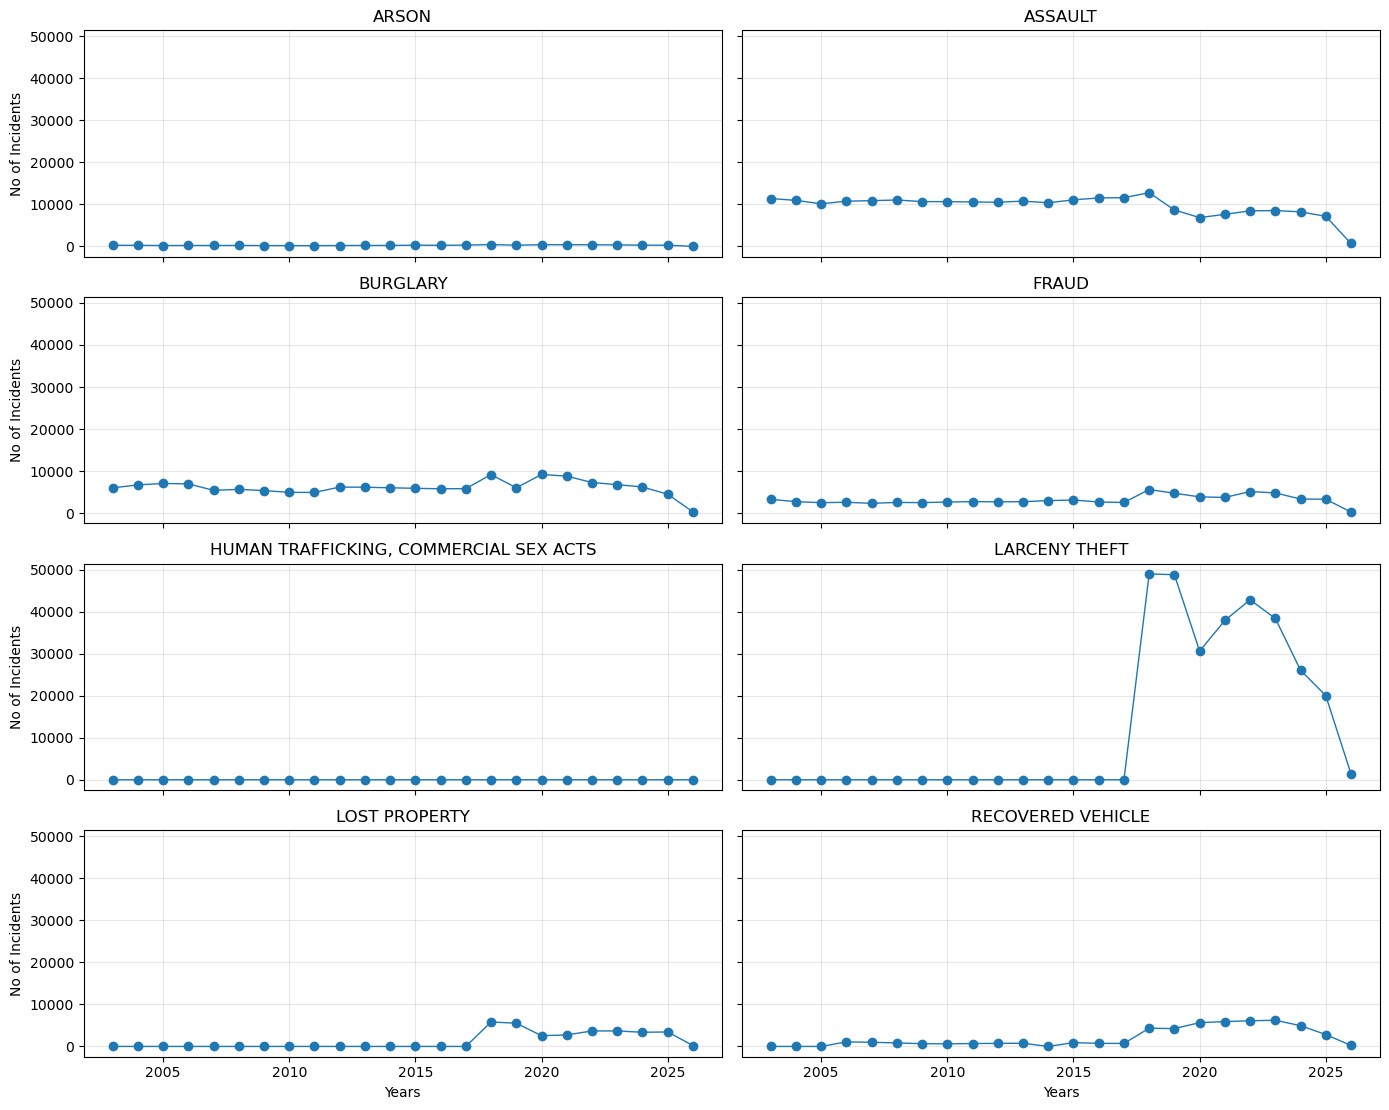

In [51]:
import matplotlib.pyplot as plt
import numpy as np
import math

# plot
cols = df_plot.columns
years = df_plot.index

labels =[c[1] if isinstance(c, tuple) else str(c) for c in cols]
n = len(labels)

# Setup
n = len(labels)
ncols = 2
nrows = math.ceil(n/ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 2.8 * nrows), sharex=True, sharey=True)
axes = axes.ravel()  # make it 1D so we can index easily

# Plot for each type of crime
for ax, col, label in zip(axes, cols, labels):
       ax.plot(years, df_plot[col],marker="o", linewidth=1)
       ax.set_title(label)
       ax.grid(True, alpha=0.3)
       
for ax in axes[::2]:
       ax.set_ylabel('No of Incidents')
       
for ax in axes[6:]:
       ax.set_xlabel('Years')
       
fig.tight_layout()
       
plt.show()